# Experiment: ESS and MESS Uniform with Varying M

This notebook compares ESS (MESS with M=1) and MESS uniform for varying number of proposals M = [2, 5, 10, 50, 100, 500, 1000] on a GP regression problem with D=5 dimensions. We track the number of intervals (shrinking steps) as a function of M.

In [1]:
import sys
import os
import time

# Get absolute path to src directory (go up from notebooks to repo root)
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(repo_root, 'src')
sys.path.insert(0, src_path)

print(f"Repo root: {repo_root}")
print(f"Added to path: {src_path}")

import numpy as np
import matplotlib.pyplot as plt
from mess.data.gp_regression import generate_gp_regression_data
from mess.problems.gp_regression import GaussianProcessRegression
from mess.algorithms.ess import ess_step
from mess.algorithms.mess import mess_step


Repo root: /Users/guillers/Documents/GitHub/mess
Added to path: /Users/guillers/Documents/GitHub/mess/src


## Experiment Setup

In [2]:
# Problem parameters
D = 5  # Dimension
num_data = 200
length_scale = 1.0
noise_variance = 0.09

# Sampler parameters
n_iters = 1000  # Number of MCMC iterations
burn_in = 100
seed = 42

# MESS M values to test
M_values = [1, 2, 5, 10, 25, 50, 75, 100, 500, 1000]

print(f"Experiment setup:")
print(f"  D = {D}")
print(f"  num_data = {num_data}")
print(f"  n_iters = {n_iters}")
print(f"  M values: {M_values}")


Experiment setup:
  D = 5
  num_data = 200
  n_iters = 1000
  M values: [1, 2, 5, 10, 25, 50, 75, 100, 500, 1000]


## Generate GP Regression Data

In [3]:
data = generate_gp_regression_data(
    num_data=num_data,
    num_dims=D,
    length_scale=length_scale,
    noise_variance=noise_variance,
    seed=seed,
)

X = data["X"]
y = data["y"]
x0 = data["f_init"]

print(f"Data shapes:")
print(f"  X: {X.shape}")
print(f"  y: {y.shape}")
print(f"  x0: {x0.shape}")

# Create the problem
problem = GaussianProcessRegression(
    X=X,
    y=y,
    length_scale=length_scale,
    noise_variance=noise_variance,
)
print(f"Initial log-likelihood: {problem.log_likelihood(x0):.4f}")


Data shapes:
  X: (5, 200)
  y: (200,)
  x0: (200,)
Initial log-likelihood: -2426.8620


## Run Experiments with Different M Values

For each M value, we run a full MCMC chain and collect statistics on the number of intervals (shrinking steps) performed by the algorithm.


In [4]:
# Store results
results = {
    'M_values': M_values,
    'mean_intervals': [],
    'std_intervals': [],
    'median_intervals': [],
    'chains': {},
    'intervals': {},
    'times': [],
}

# Run experiments for each M value
for M in M_values:
    print(f"\nRunning MESS with M = {M}...")
    
    # Initialize RNG and chain storage
    rng = np.random.default_rng(seed)
    chain = np.zeros((n_iters, num_data))
    intervals = np.zeros(n_iters, dtype=int)
    x = x0.copy()
    
    # Run MCMC
    t0 = time.time()
    for t in range(n_iters):
        x, nr_intervals, _ = mess_step(x, problem, rng, M=M, use_lp=False)
        chain[t] = x
        intervals[t] = nr_intervals
    elapsed = time.time() - t0
    
    # Compute statistics (excluding burn-in)
    intervals_post_burnin = intervals[burn_in:]
    mean_intervals = np.mean(intervals_post_burnin)
    std_intervals = np.std(intervals_post_burnin)
    median_intervals = np.median(intervals_post_burnin)
    
    # Store results
    results['mean_intervals'].append(mean_intervals)
    results['std_intervals'].append(std_intervals)
    results['median_intervals'].append(median_intervals)
    results['chains'][M] = chain
    results['intervals'][M] = intervals
    results['times'].append(elapsed)
    
    print(f"  Mean intervals: {mean_intervals:.4f} ± {std_intervals:.4f}")
    print(f"  Median intervals: {median_intervals:.1f}")
    print(f"  Time: {elapsed:.2f} seconds")

print("\n" + "="*60)
print("Experiment completed!")



Running MESS with M = 1...
  Mean intervals: 6.9967 ± 3.4307
  Median intervals: 7.0
  Time: 0.12 seconds

Running MESS with M = 2...
  Mean intervals: 3.9244 ± 1.9559
  Median intervals: 4.0
  Time: 0.10 seconds

Running MESS with M = 5...
  Mean intervals: 1.9800 ± 1.0444
  Median intervals: 2.0
  Time: 0.08 seconds

Running MESS with M = 10...
  Mean intervals: 1.3089 ± 0.7529
  Median intervals: 1.0
  Time: 0.08 seconds

Running MESS with M = 25...
  Mean intervals: 0.7367 ± 0.5623
  Median intervals: 1.0
  Time: 0.09 seconds

Running MESS with M = 50...
  Mean intervals: 0.5144 ± 0.5042
  Median intervals: 1.0
  Time: 0.13 seconds

Running MESS with M = 75...
  Mean intervals: 0.4211 ± 0.4937
  Median intervals: 0.0
  Time: 0.17 seconds

Running MESS with M = 100...
  Mean intervals: 0.3200 ± 0.4665
  Median intervals: 0.0
  Time: 0.19 seconds

Running MESS with M = 500...
  Mean intervals: 0.0267 ± 0.1611
  Median intervals: 0.0
  Time: 0.65 seconds

Running MESS with M = 1000..

## Plot Results: Number of Intervals vs M

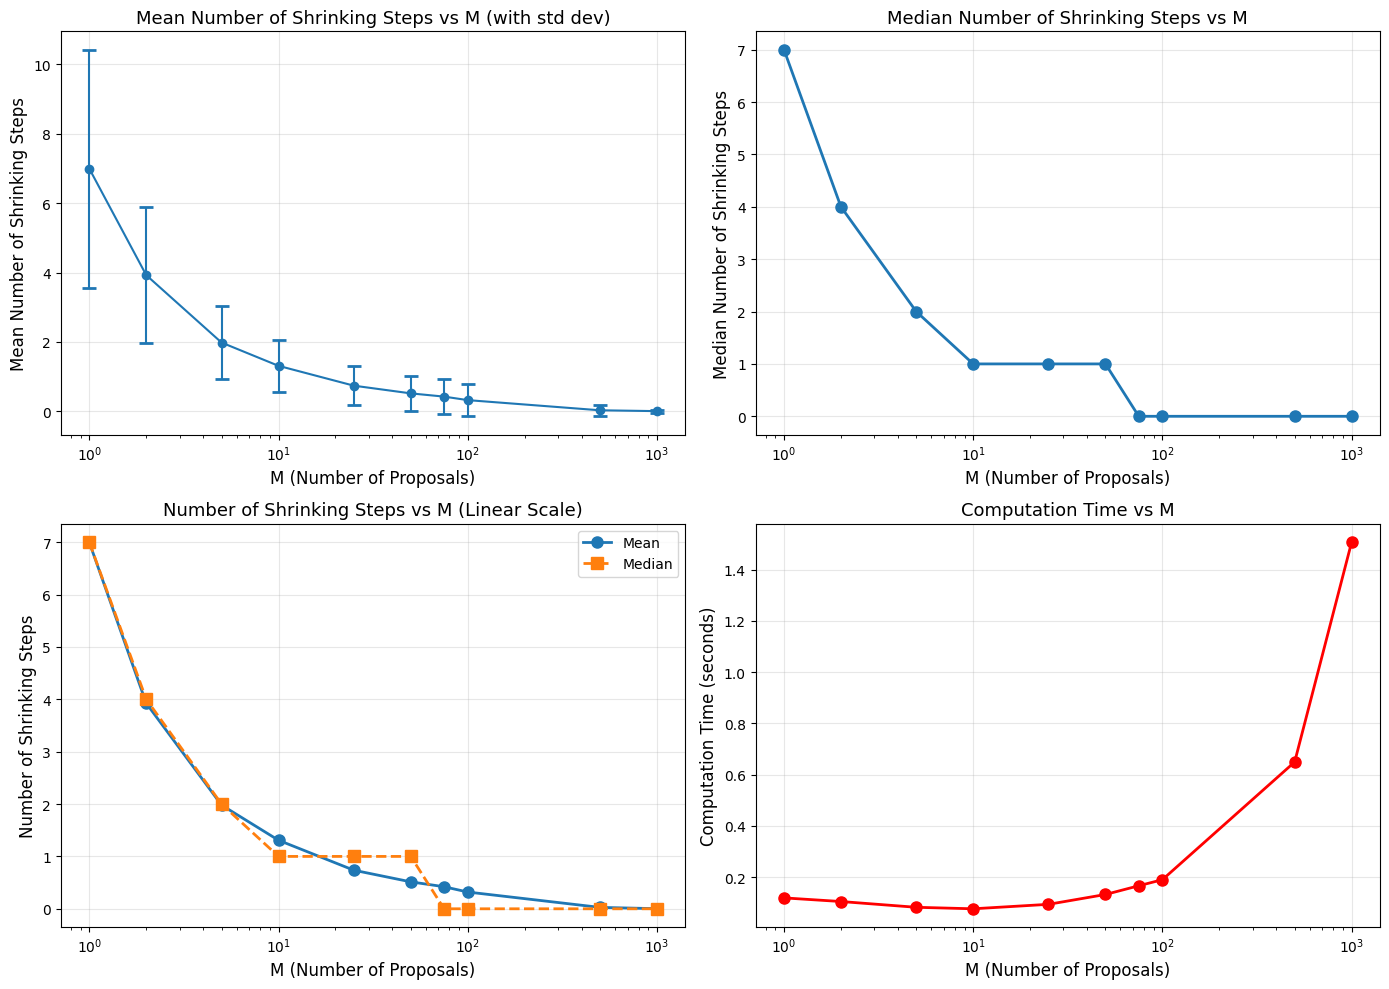


Summary Table:
M          Mean Int.       Std Dev         Median          Time (s)       
1          6.9967          3.4307          7.0             0.1192         
2          3.9244          1.9559          4.0             0.1050         
5          1.9800          1.0444          2.0             0.0825         
10         1.3089          0.7529          1.0             0.0766         
25         0.7367          0.5623          1.0             0.0940         
50         0.5144          0.5042          1.0             0.1324         
75         0.4211          0.4937          0.0             0.1665         
100        0.3200          0.4665          0.0             0.1902         
500        0.0267          0.1611          0.0             0.6495         
1000       0.0022          0.0471          0.0             1.5074         


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Mean number of intervals with error bars
ax = axes[0, 0]
ax.errorbar(results['M_values'], results['mean_intervals'], 
            yerr=results['std_intervals'], fmt='o-', capsize=5, capthick=2)
ax.set_xlabel('M (Number of Proposals)', fontsize=12)
ax.set_ylabel('Mean Number of Shrinking Steps', fontsize=12)
ax.set_title('Mean Number of Shrinking Steps vs M (with std dev)', fontsize=13)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Plot 2: Median number of intervals
ax = axes[0, 1]
ax.plot(results['M_values'], results['median_intervals'], 'o-', linewidth=2, markersize=8)
ax.set_xlabel('M (Number of Proposals)', fontsize=12)
ax.set_ylabel('Median Number of Shrinking Steps', fontsize=12)
ax.set_title('Median Number of Shrinking Steps vs M', fontsize=13)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Plot 3: Linear scale for comparison
ax = axes[1, 0]
ax.plot(results['M_values'], results['mean_intervals'], 'o-', linewidth=2, markersize=8, label='Mean')
ax.plot(results['M_values'], results['median_intervals'], 's--', linewidth=2, markersize=8, label='Median')
ax.set_xlabel('M (Number of Proposals)', fontsize=12)
ax.set_ylabel('Number of Shrinking Steps', fontsize=12)
ax.set_title('Number of Shrinking Steps vs M (Linear Scale)', fontsize=13)
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Computation time
ax = axes[1, 1]
ax.plot(results['M_values'], results['times'], 'o-', linewidth=2, markersize=8, color='red')
ax.set_xlabel('M (Number of Proposals)', fontsize=12)
ax.set_ylabel('Computation Time (seconds)', fontsize=12)
ax.set_title('Computation Time vs M', fontsize=13)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary table
print("\nSummary Table:")
print("="*80)
print(f"{'M':<10} {'Mean Int.':<15} {'Std Dev':<15} {'Median':<15} {'Time (s)':<15}")
print("="*80)
for i, M in enumerate(results['M_values']):
    print(f"{M:<10} {results['mean_intervals'][i]:<15.4f} {results['std_intervals'][i]:<15.4f} {results['median_intervals'][i]:<15.1f} {results['times'][i]:<15.4f}")
print("="*80)


## Trace Plots: Number of Intervals Over Iterations

Visualize how the number of intervals evolves during the MCMC chain for different M values.


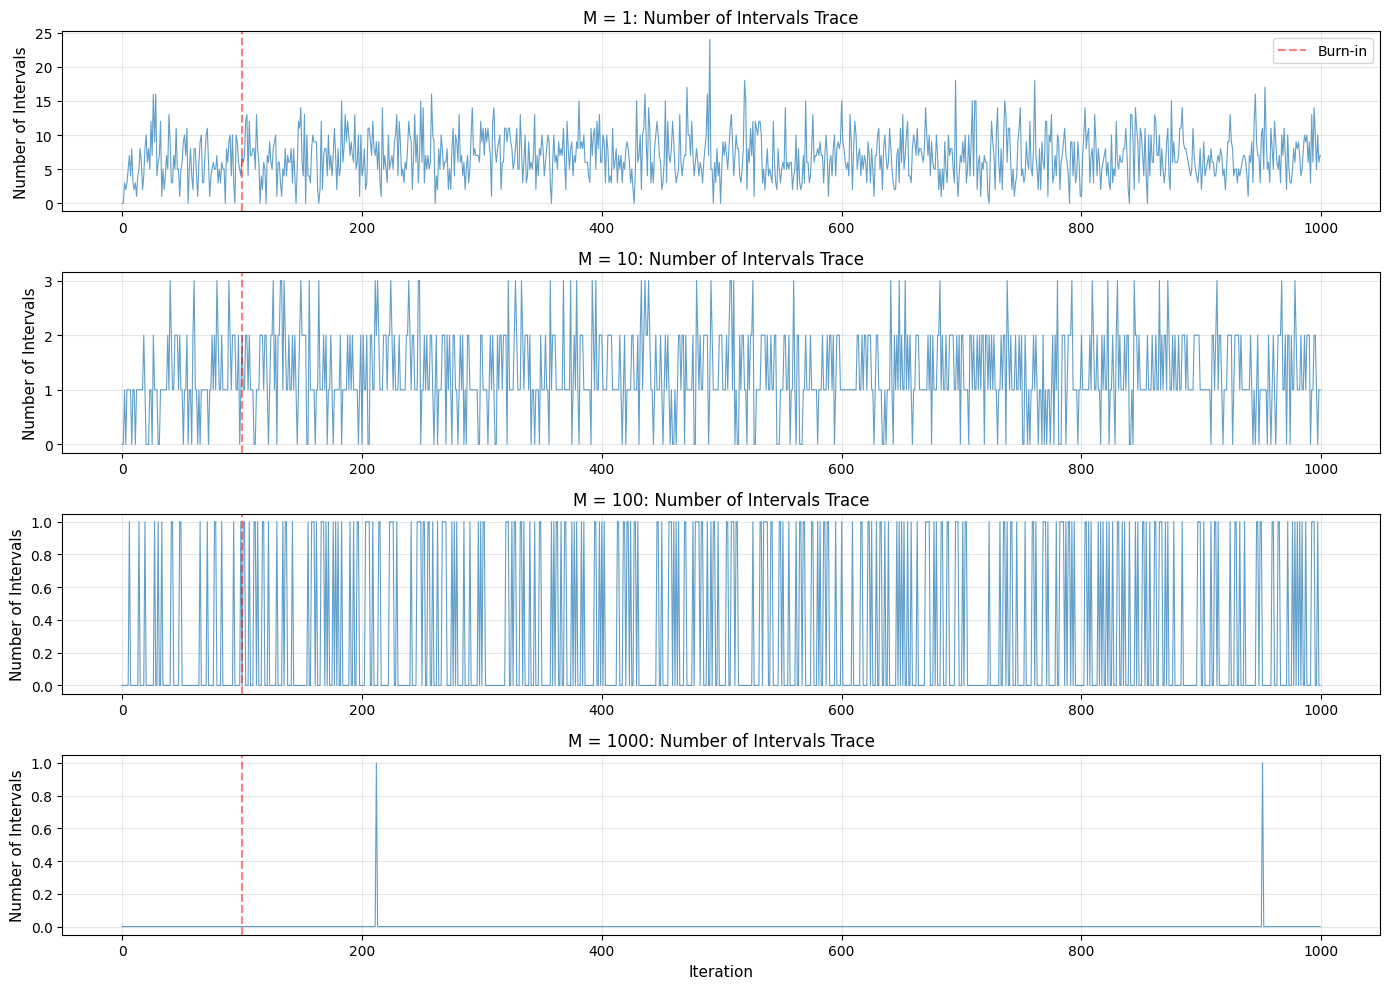

In [ ]:
# Select a subset of M values for trace plot visualization
M_subset = [1, 10, 100]

fig, axes = plt.subplots(len(M_subset), 1, figsize=(14, 10))

for idx, M in enumerate(M_subset):
    ax = axes[idx]
    intervals_trace = results['intervals'][M]
    ax.plot(intervals_trace, alpha=0.7, linewidth=0.8)
    ax.axvline(burn_in, color='red', linestyle='--', alpha=0.5, label='Burn-in')
    ax.set_ylabel('Number of Intervals', fontsize=11)
    ax.set_title(f'M = {M}: Number of Intervals Trace', fontsize=12)
    ax.grid(True, alpha=0.3)
    if idx == len(M_subset) - 1:
        ax.set_xlabel('Iteration', fontsize=11)
    if idx == 0:
        ax.legend()

plt.tight_layout()
plt.show()


## Box Plots: Distribution of Intervals for Each M

Compare the distribution of number of intervals across different M values.


/var/folders/jw/64vkfdg1407__zgldz2hpjfr0000gn/T/ipykernel_2500/1275172090.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=labels, patch_artist=True)


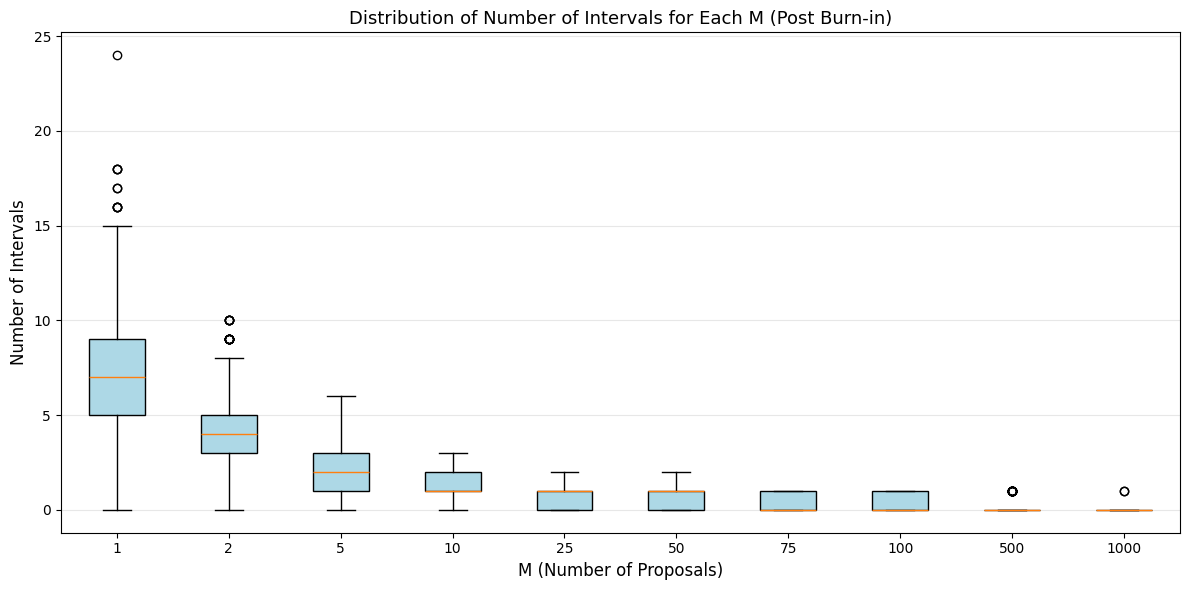


Detailed Statistics (Post Burn-in):
M          Min        Q1         Median     Q3         Max       
1          0          5          7          9          24        
2          0          3          4          5          10        
5          0          1          2          3          6         
10         0          1          1          2          3         
25         0          0          1          1          2         
50         0          0          1          1          2         
75         0          0          0          1          1         
100        0          0          0          1          1         
500        0          0          0          0          1         
1000       0          0          0          0          1         


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for box plot (post burn-in only)
box_data = [results['intervals'][M][burn_in:] for M in results['M_values']]
labels = [str(M) for M in results['M_values']]

bp = ax.boxplot(box_data, labels=labels, patch_artist=True)

# Color the boxes
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')

ax.set_xlabel('M (Number of Proposals)', fontsize=12)
ax.set_ylabel('Number of Intervals', fontsize=12)
ax.set_title('Distribution of Number of Intervals for Each M (Post Burn-in)', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Compute some additional statistics
print("\nDetailed Statistics (Post Burn-in):")
print("="*80)
print(f"{'M':<10} {'Min':<10} {'Q1':<10} {'Median':<10} {'Q3':<10} {'Max':<10}")
print("="*80)
for M in results['M_values']:
    intervals_post = results['intervals'][M][burn_in:]
    q1, med, q3 = np.percentile(intervals_post, [25, 50, 75])
    print(f"{M:<10} {int(np.min(intervals_post)):<10} {int(q1):<10} {int(med):<10} {int(q3):<10} {int(np.max(intervals_post)):<10}")
print("="*80)


## Run MESS with Angular Distance

Now run the same experiment with MESS using angular distance and linear programming to compute the transition matrix.


In [ ]:
# Filter M_values to only use M <= 100 for plotting
M_values_filtered = [M for M in M_values if M <= 100]

# Store results for MESS with angular distance
results_angular = {
    'M_values': M_values_filtered,
    'mean_intervals': [],
    'std_intervals': [],
    'median_intervals': [],
    'chains': {},
    'intervals': {},
    'times': [],
}

# Run experiments for each M value with angular distance
for M in M_values_filtered:
    print(f"\nRunning MESS (angular) with M = {M}...")
    
    # Initialize RNG and chain storage
    rng = np.random.default_rng(seed)
    chain = np.zeros((n_iters, num_data))
    intervals = np.zeros(n_iters, dtype=int)
    x = x0.copy()
    
    # Run MCMC
    t0 = time.time()
    for t in range(n_iters):
        x, nr_intervals, _ = mess_step(x, problem, rng, M=M, use_lp=True, 
                                       distance_metric='angular', lam=0.05)
        chain[t] = x
        intervals[t] = nr_intervals
    elapsed = time.time() - t0
    
    # Compute statistics (excluding burn-in)
    intervals_post_burnin = intervals[burn_in:]
    mean_intervals = np.mean(intervals_post_burnin)
    std_intervals = np.std(intervals_post_burnin)
    median_intervals = np.median(intervals_post_burnin)
    
    # Store results
    results_angular['mean_intervals'].append(mean_intervals)
    results_angular['std_intervals'].append(std_intervals)
    results_angular['median_intervals'].append(median_intervals)
    results_angular['chains'][M] = chain
    results_angular['intervals'][M] = intervals
    results_angular['times'].append(elapsed)
    
    print(f"  Mean intervals: {mean_intervals:.4f} ± {std_intervals:.4f}")
    print(f"  Median intervals: {median_intervals:.1f}")
    print(f"  Time: {elapsed:.2f} seconds")

print("\n" + "="*60)
print("Experiment (Angular Distance) completed!")



Running MESS (angular) with M = 1...
  Mean intervals: 6.8800 ± 3.3594
  Median intervals: 7.0
  Time: 3.52 seconds

Running MESS (angular) with M = 2...
  Mean intervals: 3.9733 ± 2.0059
  Median intervals: 4.0
  Time: 3.22 seconds

Running MESS (angular) with M = 5...
  Mean intervals: 2.0389 ± 1.0953
  Median intervals: 2.0
  Time: 3.41 seconds

Running MESS (angular) with M = 10...
  Mean intervals: 1.3200 ± 0.7556
  Median intervals: 1.0
  Time: 3.37 seconds

Running MESS (angular) with M = 25...
  Mean intervals: 0.7900 ± 0.5630
  Median intervals: 1.0
  Time: 4.12 seconds

Running MESS (angular) with M = 50...
  Mean intervals: 0.5500 ± 0.5041
  Median intervals: 1.0
  Time: 6.44 seconds

Running MESS (angular) with M = 75...
  Mean intervals: 0.4100 ± 0.4918
  Median intervals: 0.0
  Time: 11.69 seconds

Running MESS (angular) with M = 100...
  Mean intervals: 0.3089 ± 0.4620
  Median intervals: 0.0
  Time: 19.23 seconds

Running MESS (angular) with M = 200...
  Mean intervals

## Comparison: MESS Uniform vs MESS Angular Distance

Compare the number of intervals for MESS uniform (no LP) vs MESS with angular distance (LP + angular metric).


ValueError: operands could not be broadcast together with shapes (8,) (9,) 

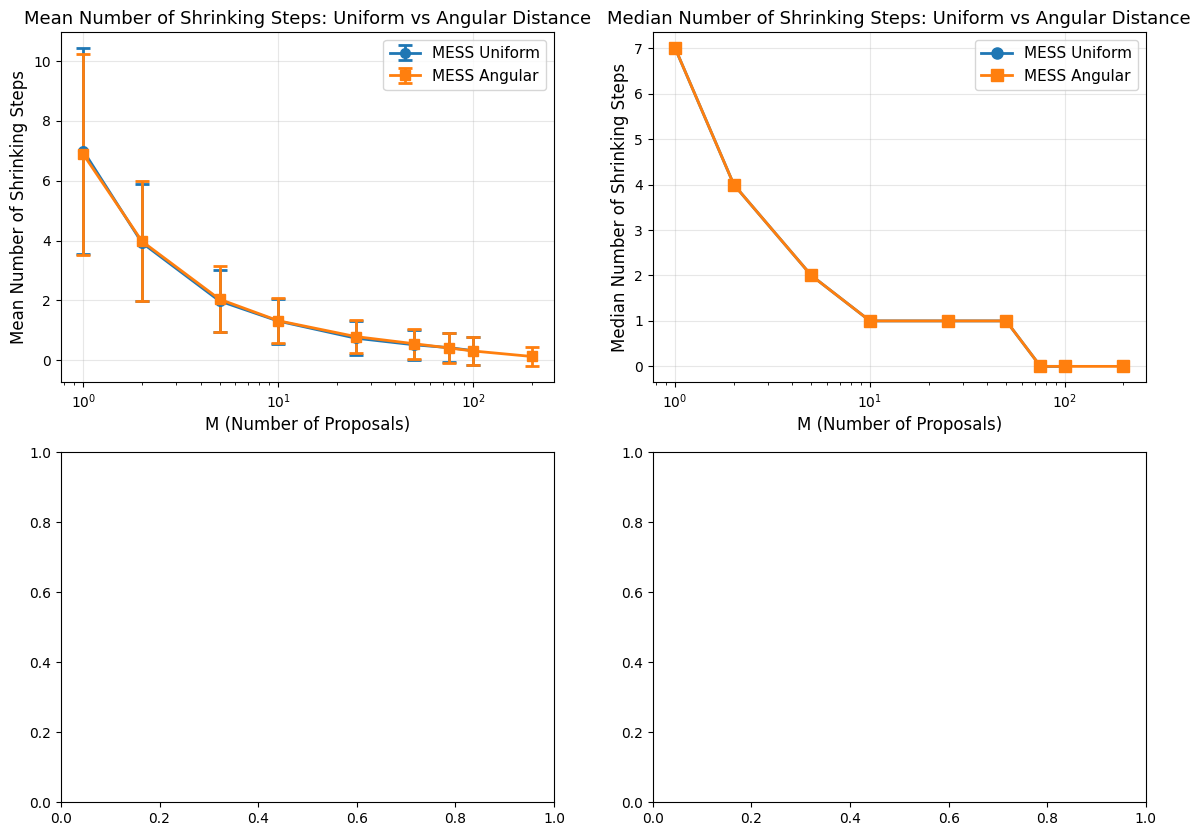

In [10]:
# Filter uniform results to match angular results (M <= 100 only)
idx_uniform_filtered = [i for i, M in enumerate(results['M_values']) if M <= 100]
M_compare = [M for M in results['M_values'] if M <= 100]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Mean comparison with error bars
ax = axes[0, 0]
uniform_mean_filtered = [results['mean_intervals'][i] for i in idx_uniform_filtered]
uniform_std_filtered = [results['std_intervals'][i] for i in idx_uniform_filtered]
ax.errorbar(M_compare, uniform_mean_filtered, 
            yerr=uniform_std_filtered, fmt='o-', capsize=5, capthick=2, 
            label='MESS Uniform', linewidth=2, markersize=7)
ax.errorbar(results_angular['M_values'], results_angular['mean_intervals'], 
            yerr=results_angular['std_intervals'], fmt='s-', capsize=5, capthick=2, 
            label='MESS Angular', linewidth=2, markersize=7)
ax.set_xlabel('M (Number of Proposals)', fontsize=12)
ax.set_ylabel('Mean Number of Shrinking Steps', fontsize=12)
ax.set_title('Mean Number of Shrinking Steps: Uniform vs Angular Distance', fontsize=13)
ax.set_xscale('log')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 2: Median comparison
ax = axes[0, 1]
uniform_median_filtered = [results['median_intervals'][i] for i in idx_uniform_filtered]
ax.plot(M_compare, uniform_median_filtered, 'o-', linewidth=2, markersize=8, 
        label='MESS Uniform')
ax.plot(results_angular['M_values'], results_angular['median_intervals'], 's-', linewidth=2, markersize=8, 
        label='MESS Angular')
ax.set_xlabel('M (Number of Proposals)', fontsize=12)
ax.set_ylabel('Median Number of Shrinking Steps', fontsize=12)
ax.set_title('Median Number of Shrinking Steps: Uniform vs Angular Distance', fontsize=13)
ax.set_xscale('log')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 3: Difference (Uniform - Angular)
ax = axes[1, 0]
difference = np.array(uniform_mean_filtered) - np.array(results_angular['mean_intervals'])
colors = ['green' if d > 0 else 'red' for d in difference]
ax.bar(range(len(M_compare)), difference, color=colors, alpha=0.7)
ax.set_xticks(range(len(M_compare)))
ax.set_xticklabels([str(m) for m in M_compare], rotation=45)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('M (Number of Proposals)', fontsize=12)
ax.set_ylabel('Mean Shrinking Steps Difference', fontsize=12)
ax.set_title('Difference in Mean Shrinking Steps (Uniform - Angular)\nGreen: Uniform has more, Red: Angular has more', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Computation time comparison
ax = axes[1, 1]
uniform_times_filtered = [results['times'][i] for i in idx_uniform_filtered]
x_pos = np.arange(len(M_compare))
width = 0.35
ax.bar(x_pos - width/2, uniform_times_filtered, width, label='MESS Uniform', alpha=0.8)
ax.bar(x_pos + width/2, results_angular['times'], width, label='MESS Angular', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([str(m) for m in M_compare], rotation=45)
ax.set_xlabel('M (Number of Proposals)', fontsize=12)
ax.set_ylabel('Computation Time (seconds)', fontsize=12)
ax.set_title('Computation Time Comparison', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print comparison table
print("\nComparison Table:")
print("="*120)
print(f"{'M':<10} {'Uniform Mean':<15} {'Angular Mean':<15} {'Difference':<15} {'Uniform Med':<15} {'Angular Med':<15}")
print("="*120)
for i in range(len(M_compare)):
    M = M_compare[i]
    uniform_mean = uniform_mean_filtered[i]
    angular_mean = results_angular['mean_intervals'][i]
    diff = uniform_mean - angular_mean
    uniform_med = uniform_median_filtered[i]
    angular_med = results_angular['median_intervals'][i]
    print(f"{M:<10} {uniform_mean:<15.4f} {angular_mean:<15.4f} {diff:<15.4f} {uniform_med:<15.1f} {angular_med:<15.1f}")
print("="*120)


## Combined Line Plot: Comparing All Methods

A comprehensive line plot showing both MESS uniform and MESS angular side by side.


ValueError: 'x' has size 8, but 'y2' has an unequal size of 9

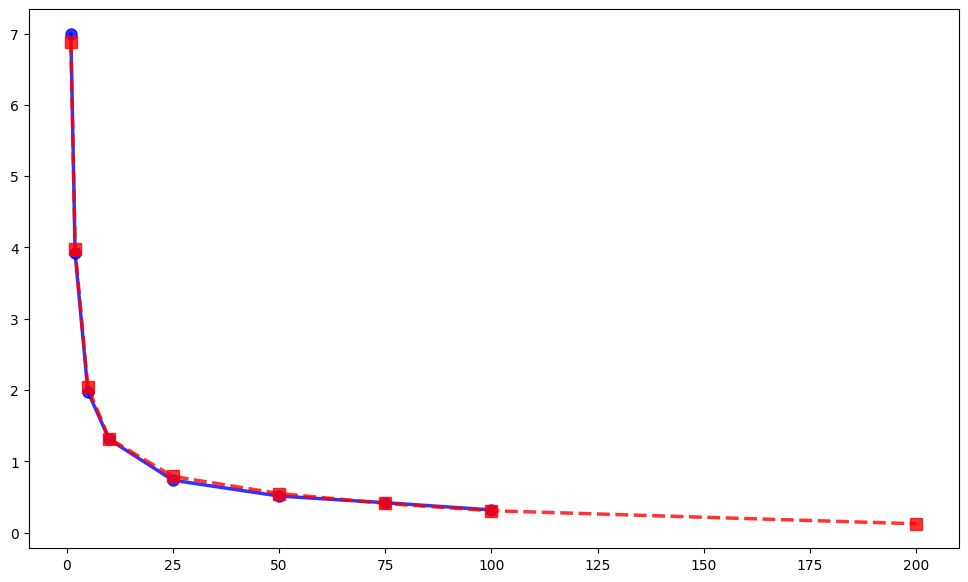

In [11]:
fig, ax = plt.subplots(figsize=(12, 7))

# Plot both methods with clear distinction (only up to M=100)
ax.plot(M_compare, uniform_mean_filtered, 'o-', linewidth=2.5, markersize=8, 
        label='MESS Uniform', color='blue', alpha=0.8)
ax.plot(results_angular['M_values'], results_angular['mean_intervals'], 's--', linewidth=2.5, markersize=8, 
        label='MESS Angular Distance', color='red', alpha=0.8)

# Fill between to show the difference
ax.fill_between(M_compare, uniform_mean_filtered, results_angular['mean_intervals'], 
                alpha=0.2, color='gray')

ax.set_xlabel('M (Number of Proposals)', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Number of Shrinking Steps', fontsize=13, fontweight='bold')
ax.set_title('MESS Uniform vs MESS Angular Distance: Number of Shrinking Steps vs M (M ≤ 100)', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

# Print which method is better for each M
print("\nMethod Comparison:")
print("="*80)
print(f"{'M':<10} {'MESS Uniform':<20} {'MESS Angular':<20} {'Better Method':<20}")
print("="*80)
for i in range(len(M_compare)):
    M = M_compare[i]
    uniform = uniform_mean_filtered[i]
    angular = results_angular['mean_intervals'][i]
    better = 'MESS Angular' if angular < uniform else 'MESS Uniform'
    improvement = abs(uniform - angular) / uniform * 100
    print(f"{M:<10} {uniform:<20.4f} {angular:<20.4f} {better:<20} ({improvement:.1f}%)")
print("="*80)
